# How Sleep Affects Health Outcomes

>Name: Brynn O'Toole

## Python Setup

Importing all the necessary libraries for this project.

In [66]:
%config InlineBackend.figure_format = 'retina'

In [67]:
# Import packages for numerical computation, statistics, plotting, and data wrangling
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [68]:
# import the required packages to create a linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split    

In [69]:
# import statsmodels for OLS regression
import statsmodels.api as sm

In [70]:
# change the matplotlib and seaborn styles to a dark theme
sns.set_style('dark')
sns.set_palette('dark')

## Introduction

Sleep is a fundamental biological process that plays a critical role in maintaining both physical and mental health. Adequate sleep supports essential functions such as immune regulation, metabolic balance, cardiovascular health, and brain performance. Research shows that insufficient sleep is linked to a wide range of negative health outcomes, including increased risk of chronic diseases like heart disease, obesity, and diabetes, as well as impaired cognitive functioning and emotional regulation . In addition to physical effects, sleep is deeply connected to mental health, as it helps regulate mood, stress responses, and the brain’s ability to process emotions. Without enough sleep, the body and mind are less equipped to recover from daily stressors, leading to both short-term and long-term health consequences. [Arambh Sanjay Shah](https://journals.sagepub.com/doi/10.1177/15598276251346752)

A growing body of research highlights a strong relationship between sleep duration and mental health outcomes, particularly stress and anxiety. Studies consistently show that people who experience sleep deprivation report higher levels of emotional distress, including increased anxiety and reduced ability to manage stress effectively. For example, research from the American Psychological Association found that chronic sleep loss can *undermine emotional functioning* and increase the risk of anxiety symptoms [Palmer, C. A.](https://psycnet.apa.org/record/2024-34959-001?doi=1). Similarly, otherwise healthy individuals often experience heightened anxiety and distress after poor sleep, demonstrating that even short-term sleep deprivation can negatively affect emotional stability [Arambh Sanjay Shah](https://journals.sagepub.com/doi/10.1177/15598276251346752). These findings suggest that people who sleep less are indeed more likely to report higher levels of stress and anxiety.

Importantly, the relationship between sleep and mental health is bidirectional, meaning that poor sleep can increase stress and anxiety, while stress and anxiety can also disrupt sleep. Research shows that individuals with insomnia are significantly more likely to experience anxiety disorders, and sleep deprivation reduces the brain’s ability to regulate emotions effectively . At the same time, stress itself can directly impair sleep quality, creating a cycle in which poor sleep and heightened stress reinforce one another . The evidence clearly indicates that sleep is a key factor in health outcomes, and that insufficient sleep is strongly associated with higher levels of stress and anxiety, making it an important area of focus for improving overall well-being.

The aim of this project is to analyze the relationship between sleep patterns and health outcomes using data-driven methods, identifying key associations between sleep duration, quality, and various physical health measures.

## Background: The Relationship Between Sleep and Health Outcomes

Sleep is a fundamental biological process essential for maintaining physical, cognitive, and emotional health. It plays a critical role in regulating numerous physiological systems, including metabolic, cardiovascular, immune, and neurological functions. In recent decades, sleep has become a major focus in public health research due to increasing rates of sleep deprivation and sleep disorders worldwide. Modern lifestyle factors, such as longer work hours, increased screen exposure, and shift based employment, have contributed to widespread disruptions in both sleep duration and quality [Zimmerman M](https://www.sleephealthjournal.org/article/S2352-7218(23)00293-0/abstract?utm_source=chatgpt.com).

Adequate sleep is typically defined as 7–9 hours per night for adults, though both sleep quantity and quality are important determinants of health [Gao C](10.3389/fmed.2021.813943). Research increasingly shows that deviations from this range,either short sleep (generally <6–7 hours) or long sleep (>8–9 hours), are associated with a wide range of adverse health outcomes. Large-scale meta-analyses and umbrella reviews have demonstrated that short sleep duration is linked to increased risks of obesity, hypertension, and metabolic disorders, while long sleep duration is associated with elevated risks of stroke and all cause mortality [Gao C](10.3389/fmed.2021.813943). These findings highlight that sleep has a nonlinear relationship with health outcomes, where both insufficient and excessive sleep may signal or contribute to underlying health issues.

One of the primary pathways through which sleep affects health is through metabolic and cardiovascular regulation. Sleep deprivation has been shown to impair glucose metabolism and increase insulin resistance, contributing to the development of type 2 diabetes [NHLBI](https://www.nhlbi.nih.gov/sites/default/files/media/docs/NHLBI_Constituency_Report_2024_SleepHealth_2024.pdf?utm_source=chatgpt.com). Additionally, chronic insufficient sleep is associated with elevated blood pressure and increased risk of cardiovascular disease. Disruptions in circadian rhythms, such as those experienced by shift workers, further exacerbate these risks by misaligning internal biological clocks with environmental cues, leading to long-term physiological stress and inflammation [Regalla S](https://impactfactor.org/PDF/IJTPR/14/IJTPR%2CVol14%2CIssue9%2CArticle5.pdf?utm_source=chatgpt.com).

Sleep also plays a crucial role in brain health and cognitive functioning. During sleep, the brain undergoes processes essential for memory consolidation, emotional regulation, and the removal of metabolic waste products. Disturbed sleep has been linked to impaired cognitive performance, reduced attention, and increased risk of neurodegenerative diseases such as Alzheimer’s disease and dementia [Gottesman R](https://www.ahajournals.org/doi/pdf/10.1161/STR.0000000000000453?utm_source=chatgpt.com). Emerging research suggests that sleep may facilitate the functioning of the glymphatic system, which clears neurotoxic waste from the brain, providing a biological mechanism linking poor sleep to long-term neurological decline.

Mental health outcomes are strongly associated with sleep quality as well. Insufficient or poor-quality sleep has been consistently linked to increased rates of depression, anxiety, and stress-related disorders. Meta-analytic evidence indicates that improvements in sleep quality can lead to significant reductions in symptoms of depression and anxiety, suggesting a potentially causal relationship between sleep and mental health [Scott A](https://www.sciencedirect.com/science/article/pii/S1087079221001416?via%3Dihub). Prolonged sleep deprivation has been shown to impair emotional regulation and increase vulnerability to psychiatric disorders [Palmer C](https://www.apa.org/pubs/journals/releases/bul-bul0000410.pdf?utm_source=chatgpt.com).

Beyond individual physiological systems, sleep is increasingly recognized as a multidimensional construct encompassing duration, quality, timing, and regularity. Recent research emphasizes that sleep regularity, consistent sleep and wake times, may be as important as total sleep duration in predicting health outcomes, including mortality risk and cardiometabolic health. Irregular sleep patterns can disrupt circadian rhythms and negatively affect processes such as hormone regulation, digestion, and immune function [NHLBI](https://www.nhlbi.nih.gov/sites/default/files/media/docs/NHLBI_Constituency_Report_2024_SleepHealth_2024.pdf?utm_source=chatgpt.com).

From a population health perspective, inadequate sleep represents a significant and growing public health concern. A substantial proportion of adults fail to meet recommended sleep guidelines, particularly among populations exposed to high stress, socioeconomic disadvantage, or irregular work schedules. This widespread sleep deficiency has implications not only for individual health but also for healthcare systems, productivity, and safety outcomes (e.g., increased workplace errors and accidents). As a result, sleep is increasingly viewed as a modifiable risk factor that can be targeted through behavioral interventions, policy changes, and technological innovations [Gao C](10.3389/fmed.2021.813943).

In the context of health data science, the study of sleep and health outcomes presents both opportunities and challenges. Advances in wearable technology, actigraphy, and large-scale cohort studies (e.g., UK Biobank, NHANES) have enabled the collection of high resolution sleep data, facilitating more precise modeling of sleep patterns and their associations with disease outcomes. Analytical approaches such as longitudinal modeling, machine learning, and causal inference are increasingly used to disentangle complex relationships between sleep and health [Palmer C](https://www.apa.org/pubs/journals/releases/bul-bul0000410.pdf?utm_source=chatgpt.com). However, challenges remain in standardizing sleep measurements and accounting for confounding variables such as lifestyle, comorbidities, and socioeconomic factors.

The existing body of research demonstrates that sleep is a critical determinant of health across multiple domains. Both insufficient and excessive sleep, as well as poor sleep quality and irregular sleep patterns, are associated with adverse physical, mental, and cognitive outcomes. Understanding these relationships is essential for developing effective interventions and improving population health.

## Methods

### Data Import and Verification

The data are contained in a comma-separated values file, which is imported below and assigned to the variable `df`.

In [71]:
df = pd.read_csv('/Users/brynnotoole/Documents/pubh1142/Sleep_health_and_lifestyle_dataset.csv')

We perform data verification on the data:
1. Shape
2. Information
3. Return first five rows of data

In [72]:
df.shape

(374, 13)

The dataset contains information about $374$ subjects. The dataset consists of $13$ variables.

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


The data has 13 columns with dtypes float64, int64, and object.

In [74]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## Results

### Exploratory Data Analysis

#### Sleep Disorder

The `Sleep Disorder` column contains information about the outcome of this study.  

In [75]:
df['Sleep Disorder']

0              NaN
1              NaN
2              NaN
3      Sleep Apnea
4      Sleep Apnea
          ...     
369    Sleep Apnea
370    Sleep Apnea
371    Sleep Apnea
372    Sleep Apnea
373    Sleep Apnea
Name: Sleep Disorder, Length: 374, dtype: object

In [76]:
# get rid of na values in the 'Sleep Disorder' column
df = df.dropna(subset=['Sleep Disorder'])
df['Sleep Disorder']

3      Sleep Apnea
4      Sleep Apnea
5         Insomnia
6         Insomnia
16     Sleep Apnea
          ...     
369    Sleep Apnea
370    Sleep Apnea
371    Sleep Apnea
372    Sleep Apnea
373    Sleep Apnea
Name: Sleep Disorder, Length: 155, dtype: object

In [77]:
df['Sleep Disorder'].unique()

array(['Sleep Apnea', 'Insomnia'], dtype=object)

The `Sleep Disorder` column has two outcomes: `Sleep Apnea` and `Insomnia`.

In [78]:
# Calculate the frequency of each value in the 'Sleep Disorder' column
df['Sleep Disorder'].value_counts()

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In this dataset, 78 people have `Sleep Apnea` and 77 people have `Insomnia`.

In [79]:
# Calculate the percentage of each value in the 'Sleep Disorder' column
df['Sleep Disorder'].value_counts(normalize=True) * 100

Sleep Disorder
Sleep Apnea    50.322581
Insomnia       49.677419
Name: proportion, dtype: float64

In this dataset, $50.3\%$ of people have `Sleep Apnea` and $49.7\%$ of people have `Insomnia`.

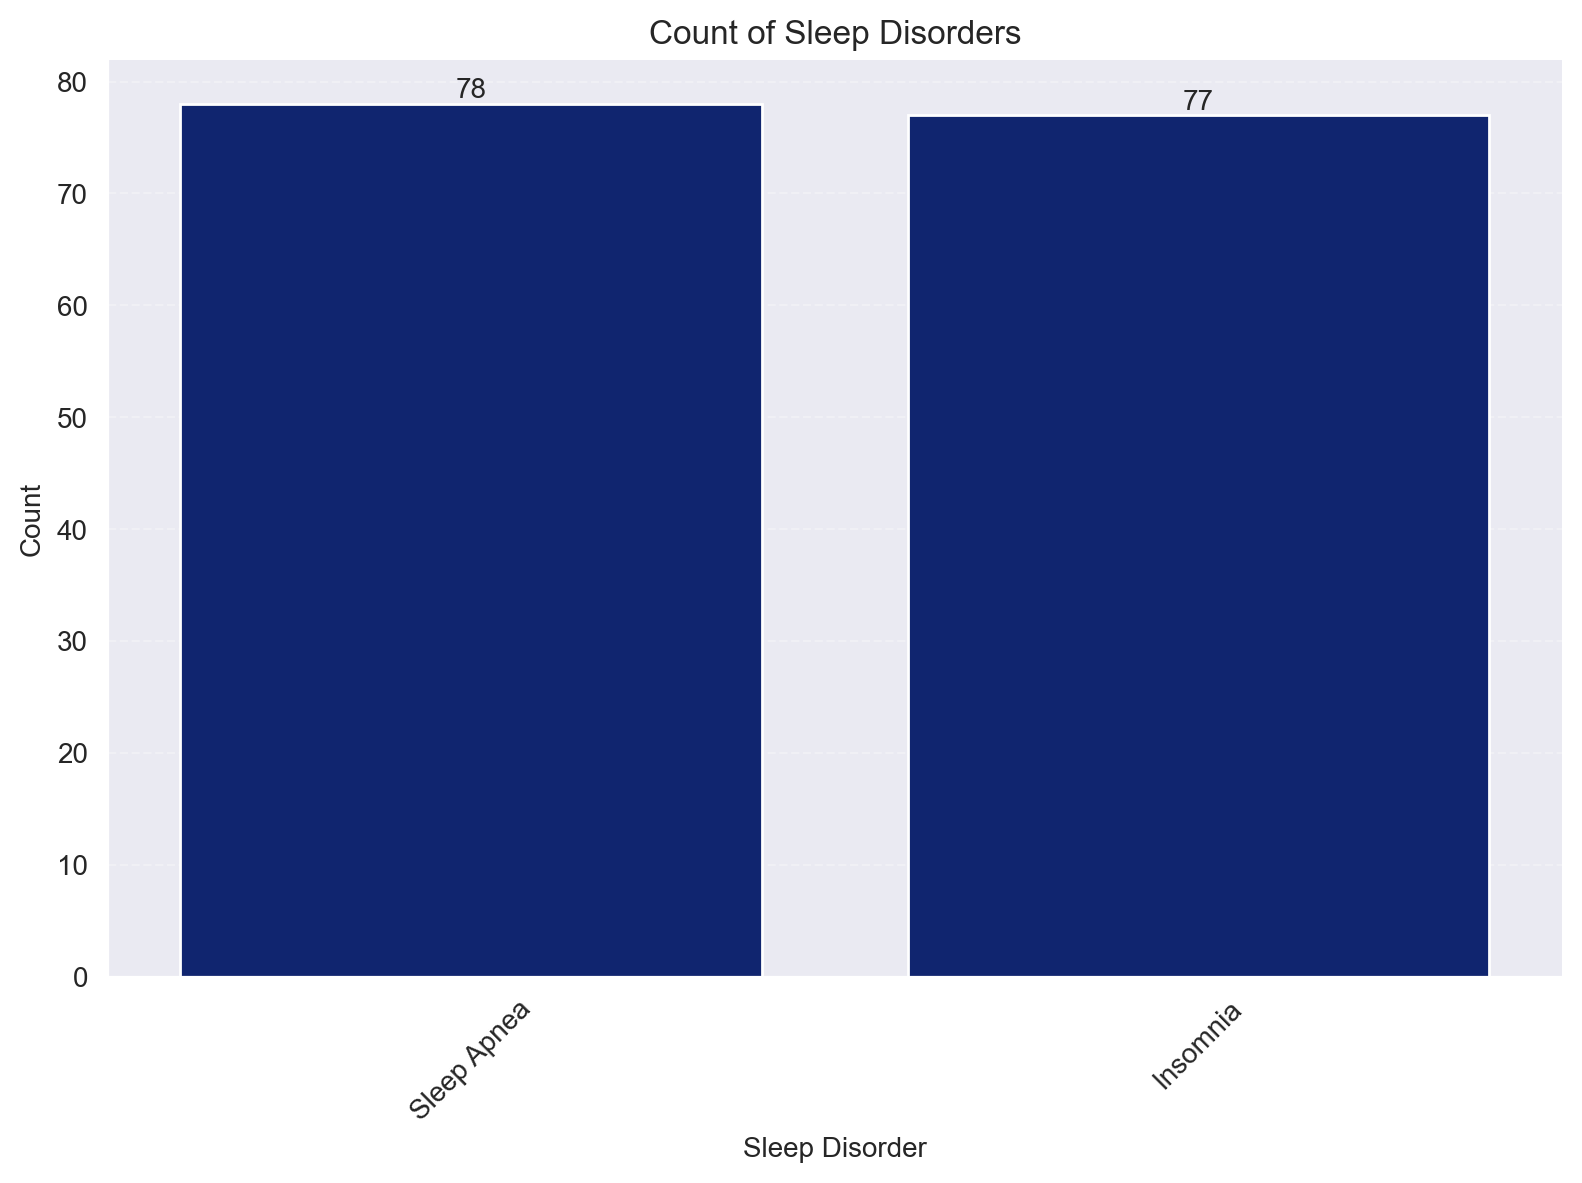

In [80]:
# use seaborn to create a countplot of the `Sleep Disorder` column to visualize the frequency of each sleep disorder category   
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x='Sleep Disorder', data=df, ax=ax)
ax.set_title('Count of Sleep Disorders')
ax.set_xlabel('Sleep Disorder')
ax.set_ylabel('Count')
plt.xticks(rotation=45)

# Remove right and top spines
sns.despine(ax=ax, right=True, top=True)

# Add horizontal grid
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add frequency above each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height,
            f'{int(height)}',
            ha="center", va="bottom")

plt.tight_layout()
plt.show()

The bar chart visually shows the amount of people with `Sleep Apnea` (78) and `Insomnia` (77).

#### Age

The `Age` column contains information contains information about the ages of the particpants.

In [81]:
# summary statistics for the `Age` column
df['Age'].describe()

count    155.000000
mean      46.632258
std        7.839311
min       28.000000
25%       43.000000
50%       45.000000
75%       51.000000
max       59.000000
Name: Age, dtype: float64

In [82]:
# calculate the interquartile range (IQR) for the `Age` column
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
print(f'IQR for Age: {IQR}')    

IQR for Age: 8.0


In [83]:
# who is the oldest and youngest person in the dataset? 
oldest_person = df.loc[df['Age'].idxmax()]
youngest_person = df.loc[df['Age'].idxmin()]
print(f'Oldest person: (Age: {oldest_person["Age"]})')
print(f'Youngest person: (Age: {youngest_person["Age"]})')

Oldest person: (Age: 59)
Youngest person: (Age: 28)


In [84]:
# Calculate summary statistics of the `Age` column grouped by the `Sleep Disorder` column
df.groupby('Sleep Disorder')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Sleep Disorder,,,,,,,,
Insomnia,77.0,43.519481,4.808464,28.0,43.0,44.0,45.00,53.0
Sleep Apnea,78.0,49.705128,8.990773,28.0,49.0,50.0,57.75,59.0


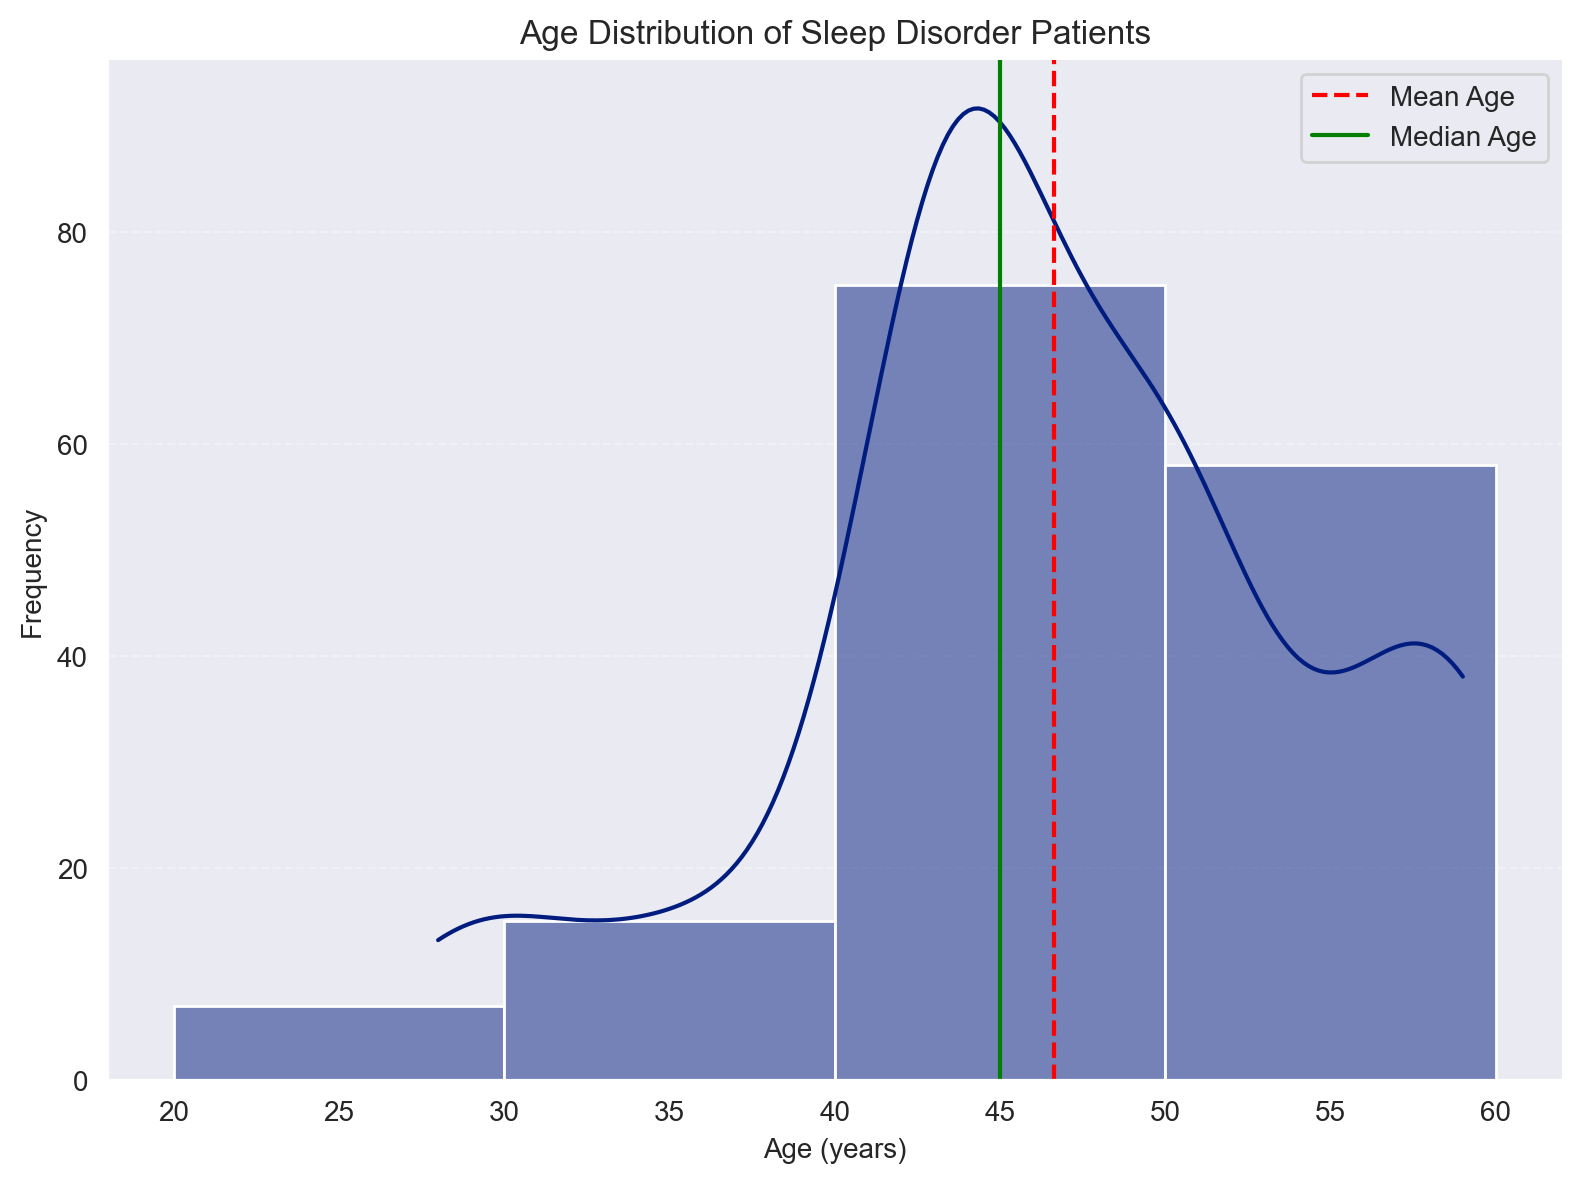

In [85]:
# create a histogram of the `Age` column to visualize the distribution of ages in the dataset
# add a title "Age Distribution of Sleep Disorder Patients" 
# add a horiztonal grid to the plot
# add a vertical line to indicate the mean age of the patients in the dataset
# get rid of right and top splins
# add horiztonal axes label "Age (years)"
# add the vertial label "Frequency"
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(df['Age'], bins=range(20, 70, 10), kde=True, ax=ax)
ax.set_title('Age Distribution of Sleep Disorder Patients')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Frequency')
sns.despine(ax=ax, right=True, top=True)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean Age')
ax.axvline(df['Age'].median(), color='green', linestyle='-', label='Median Age')
ax.legend()
plt.tight_layout()
plt.show()

According to this chart, most people are in the **40-50** year range, the *median age* is **45**, and the *mean age* is around **46**.

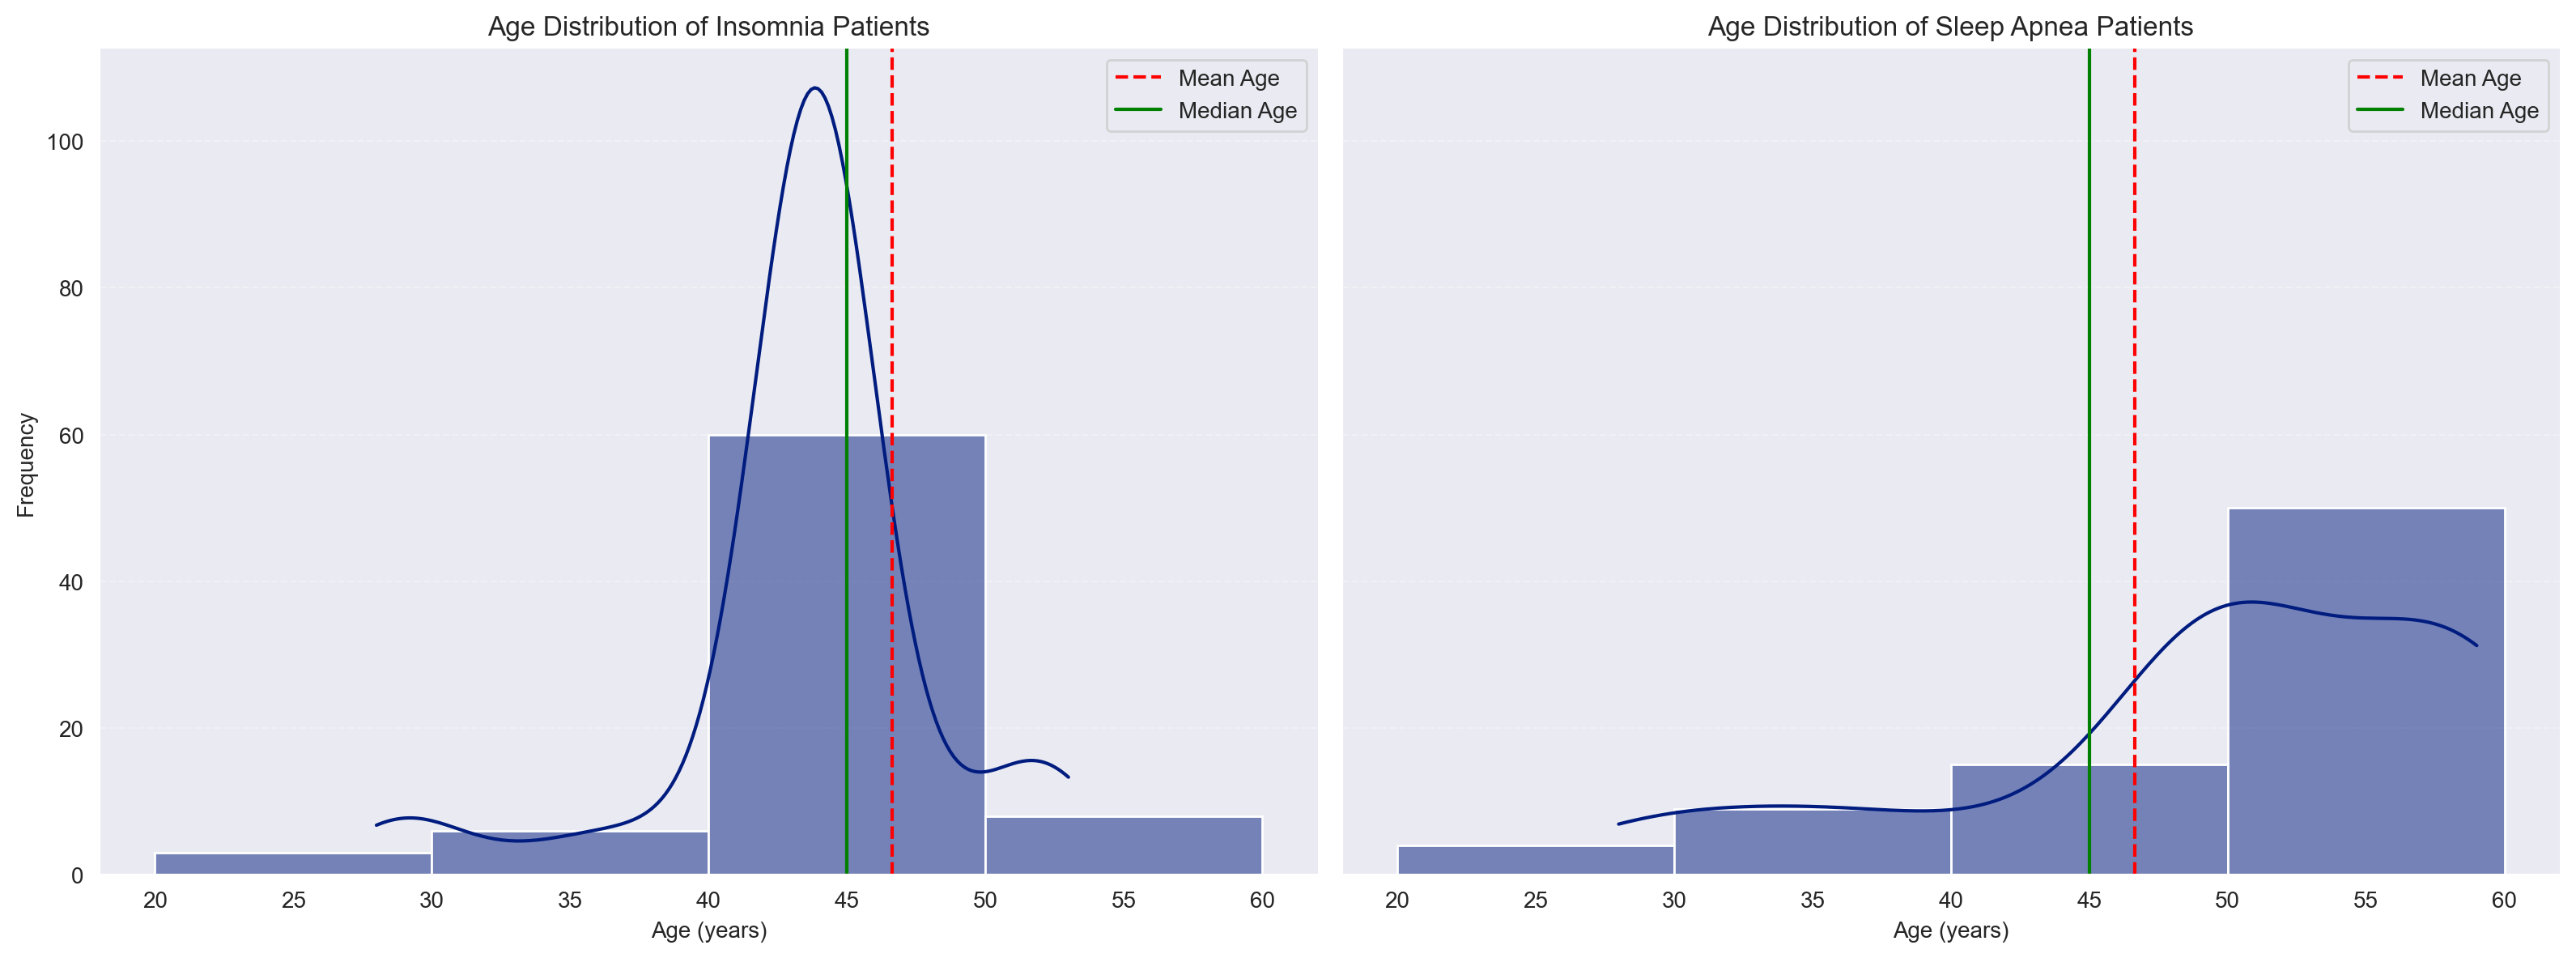

In [86]:
# recreate the previous histogram but for each category in the Sleep Disorder column
# create the two plots with one row and two columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
sns.histplot(df[df['Sleep Disorder'] == 'Insomnia']['Age'], bins=range(20, 70, 10), kde=True, ax=axes[0])
axes[0].set_title('Age Distribution of Insomnia Patients')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')
sns.despine(ax=axes[0], right=True, top=True)   
sns.histplot(df[df['Sleep Disorder'] == 'Sleep Apnea']['Age'], bins=range(20, 70, 10), kde=True, ax=axes[1])
axes[1].set_title('Age Distribution of Sleep Apnea Patients')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Frequency')
sns.despine(ax=axes[1], right=True, top=True)
for ax in axes:
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean Age')
    ax.axvline(df['Age'].median(), color='green', linestyle='-', label='Median Age')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

According to the chart on the left, most people with `Insomnia` are in the **40-50** year range, the *median age* is **45**, and the *mean age* is around **46**. According to the chart on the right, most people with `Sleep Apnea` are in the **50-60** year range, the *median age* is **45**, and the *mean age* is around **46**. 

#### BMI Category

The `BMI Category` column contains information about the BMI of the particpants in this study. 

In [87]:
df['BMI Category'].unique()

array(['Obese', 'Normal Weight', 'Normal', 'Overweight'], dtype=object)

The 4 original categories include only Obese, Normal Weight, Normal, and Overweight.

In [88]:
# combine Normal weight and normal in the `BMI Category` column into a single category called "Normal Weight"
df['BMI Category'] = df['BMI Category'].replace({'Normal Weight': 'Normal Weight', 'Normal': 'Normal Weight'})
df['BMI Category'].unique()

array(['Obese', 'Normal Weight', 'Overweight'], dtype=object)

The 3 categories now include only Obese, Normal Weight, and Overweight.

In [89]:
# Return unique values in the `BMI Category` column and their frequencies
df['BMI Category'].value_counts() 

BMI Category
Overweight       129
Normal Weight     16
Obese             10
Name: count, dtype: int64

129 participants are `Overweight`, 16 participants are `Normal Weight`, and 10 are `Obese`.

In [90]:
# Calculate the percentages of each value in the `BMI Category` column
df['BMI Category'].value_counts(normalize=True) * 100

BMI Category
Overweight       83.225806
Normal Weight    10.322581
Obese             6.451613
Name: proportion, dtype: float64

$83\%$ of participants are `Overweight`, $10\%$ of participants are `Normal Weight`, and $6\%$ are `Obese`.

In [91]:
# Return a contingency table of the `Sleep Disorder` and `BMI Category` columns
pd.crosstab(df['Sleep Disorder'], df['BMI Category'])

BMI Category,Normal Weight,Obese,Overweight
Sleep Disorder,,,
Insomnia,9,4,64
Sleep Apnea,7,6,65


In [92]:
# return a contingency table of the `Sleep Disorder` and `BMI Category` columns with row percentages
pd.crosstab(df['Sleep Disorder'], df['BMI Category'], normalize='index') * 100

BMI Category,Normal Weight,Obese,Overweight
Sleep Disorder,,,
Insomnia,11.688312,5.194805,83.116883
Sleep Apnea,8.974359,7.692308,83.333333


In [93]:
# express those as column percentages instead of row percentages
pd.crosstab(df['Sleep Disorder'], df['BMI Category'], normalize='columns') * 100

BMI Category,Normal Weight,Obese,Overweight
Sleep Disorder,,,
Insomnia,56.25,40.0,49.612403
Sleep Apnea,43.75,60.0,50.387597


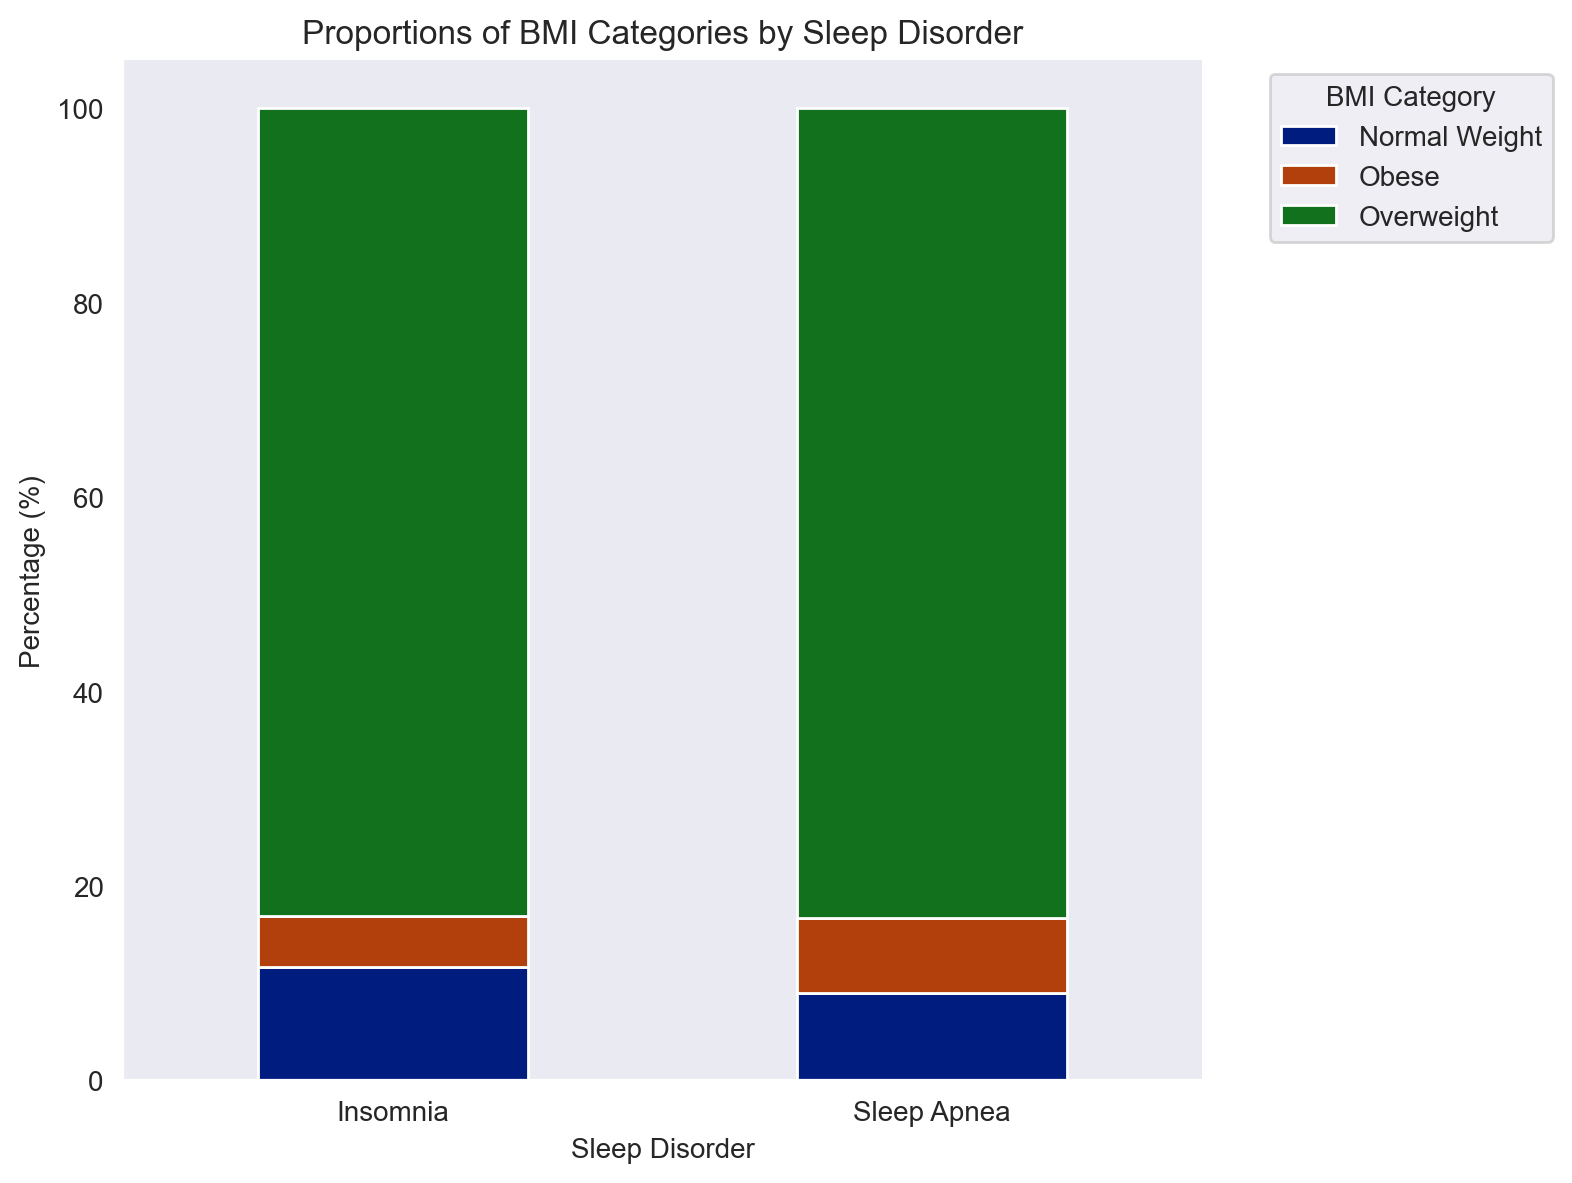

In [94]:
# create a stacked bar plot to show the proportions of each BMI category within each sleep disorder category
fig, ax = plt.subplots(figsize=(8, 6))
crosstab_data = pd.crosstab(df['Sleep Disorder'], df['BMI Category'], normalize='index') * 100
crosstab_data.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Proportions of BMI Categories by Sleep Disorder')
ax.set_xlabel('Sleep Disorder')
ax.set_ylabel('Percentage (%)')
ax.legend(title='BMI Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
sns.despine(ax=ax, right=True, top=True)
plt.tight_layout()
plt.show()

According to the visualization, most participants are `Overweight`.

#### Two numerical varaibles visualization

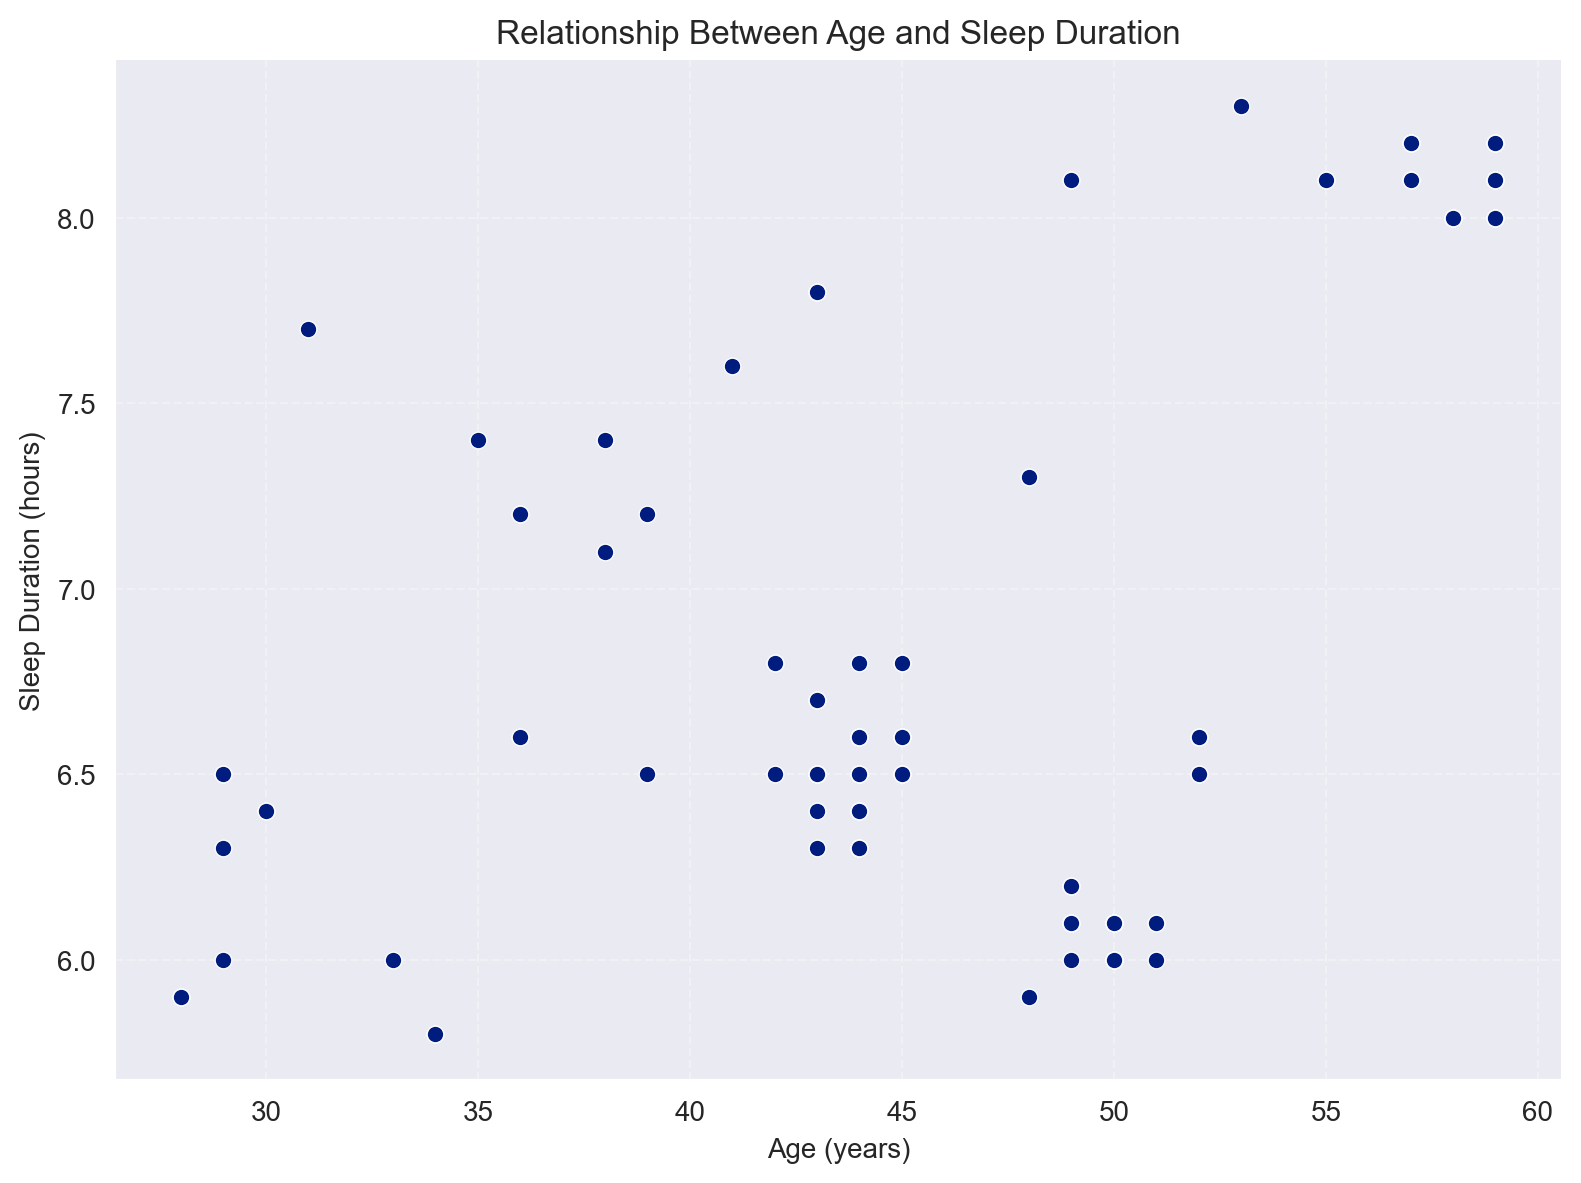

In [95]:
# create a scatterplot pf the Age column and the Sleep Duration column to visualize the relationship between age and hours of sleep for patients in the dataset
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='Age', y='Sleep Duration', data=df, ax=ax)
ax.set_title('Relationship Between Age and Sleep Duration')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Sleep Duration (hours)')
sns.despine(ax=ax, right=True, top=True)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

The scatter plot shows that `Sleep Duration` varies across ages but generally suggests a slight tendency for older individuals to report longer sleep compared to middle-aged adults, with considerable variability overall.

### Research Questions

#### Difference in Age Between Sleep Apnea and Insomnia

* $H_{0}$: There is no difference in age between populations of Sleep Disorders.

* $H_{1}$: There is no difference in age between populations of Sleep Disorders.

In [97]:
# conduct a Shapiro-Wilk test on the ages of people who have sleep apnea to test for normality
stats.shapiro(df[df['Sleep Disorder'] == 'Sleep Apnea']['Age'])

ShapiroResult(statistic=np.float64(0.8468563798106695), pvalue=np.float64(1.6821888941927893e-07))

According to the Shapiro-Wilk test, `Age` is not normally distributed in the population of people with `Sleep Apnea.`

In [98]:
stats.shapiro(df[df['Sleep Disorder'] == 'Insomnia']['Age'])

ShapiroResult(statistic=np.float64(0.775406302177063), pvalue=np.float64(1.6877630557196315e-09))

According to the Shapiro-Wilk test, `Age` is not normally distributed in the population of people with `Insomnia.`

In [99]:
# Use the Levene's test to test for homogeneity of variances between the ages of people with insomnia and sleep apnea
stats.levene(df[df['Sleep Disorder'] == 'Insomnia']['Age'], df[df['Sleep Disorder'] == 'Sleep Apnea']['Age'])

LeveneResult(statistic=np.float64(21.84721356413165), pvalue=np.float64(6.43002897173938e-06))

According to Levene's test, there is a significant difference in variance of `Age` between `Sleep Disorder` groups, indicating that the homogeneity of variances assumption is not met.

In [100]:
# Conduct an equal variances t-test to compare the mean ages of people with insomnia and sleep apnea
stats.ttest_ind(df[df['Sleep Disorder'] == 'Insomnia']['Age'], df[df['Sleep Disorder'] == 'Sleep Apnea']['Age'], equal_var=True)    

TtestResult(statistic=np.float64(-5.331103554885975), pvalue=np.float64(3.441909883139507e-07), df=np.float64(153.0))

There is enough evidence to support the claim that there is a difference between `Ages` for people with each `Sleep Disorder.`

In [101]:
# Conduct an unequal variances t-test to compare the mean ages of people with insomnia and sleep apnea
stats.ttest_ind(df[df['Sleep Disorder'] == 'Insomnia']['Age'], df[df['Sleep Disorder'] == 'Sleep Apnea']['Age'], equal_var=False)   

TtestResult(statistic=np.float64(-5.350357243376988), pvalue=np.float64(4.3679205700001946e-07), df=np.float64(118.04507943831341))

Mam-Whitney U test 

In [102]:
# Conduct a Mann-Whitney U test to compare the ages of people with insomnia and sleep apnea if the assumptions of normality and homogeneity of variances are not met
stats.mannwhitneyu(df[df['Sleep Disorder'] == 'Insomnia']['Age'], df[df['Sleep Disorder'] == 'Sleep Apnea']['Age'], alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(1433.0), pvalue=np.float64(1.6239946093558218e-08))

There is enough evidence in the data at the $5\%$ level of significance to show that there is a difference median age between the populations of `Sleep Disorders.` In fact, the median age of `Sleep Apnea` patients is six years more than patients with `Insomnia.`

#### Association between BMI and Sleep Disorders

* $H_{0}$: There is no association between BMI and Sleep Disorders.
* $H_{a}$: There is an association between BMI and Sleep Disorders.

In [103]:
# create a contingency table of the `Sleep Disorder` and `BMI Category` columns
contingency_table = pd.crosstab(df['Sleep Disorder'], df['BMI Category'])
print(contingency_table)

BMI Category    Normal Weight  Obese  Overweight
Sleep Disorder                                  
Insomnia                    9      4          64
Sleep Apnea                 7      6          65


In [104]:
# Conduct a chi-square test of independence to test for an association between sleep disorder category and BMI category
# return the test statistic, p-value, degrees of freedom, and expected frequencies for the chi-square test of independence      
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f'Chi-square statistic: {chi2}')
print(f'p-value: {p}')
print(f'Degrees of freedom: {dof}')
print('Expected frequencies:')
print(expected)

Chi-square statistic: 0.6513274354844121
p-value: 0.7220479585273512
Degrees of freedom: 2
Expected frequencies:
[[ 7.9483871   4.96774194 64.08387097]
 [ 8.0516129   5.03225806 64.91612903]]


There is not enough evidence in the data at the $5\%$ level of significance to show that there is an association between `BMI` and `Sleep Disorders.`

### Modeling

#### Is Age Linearly Associated with Stress Levels?

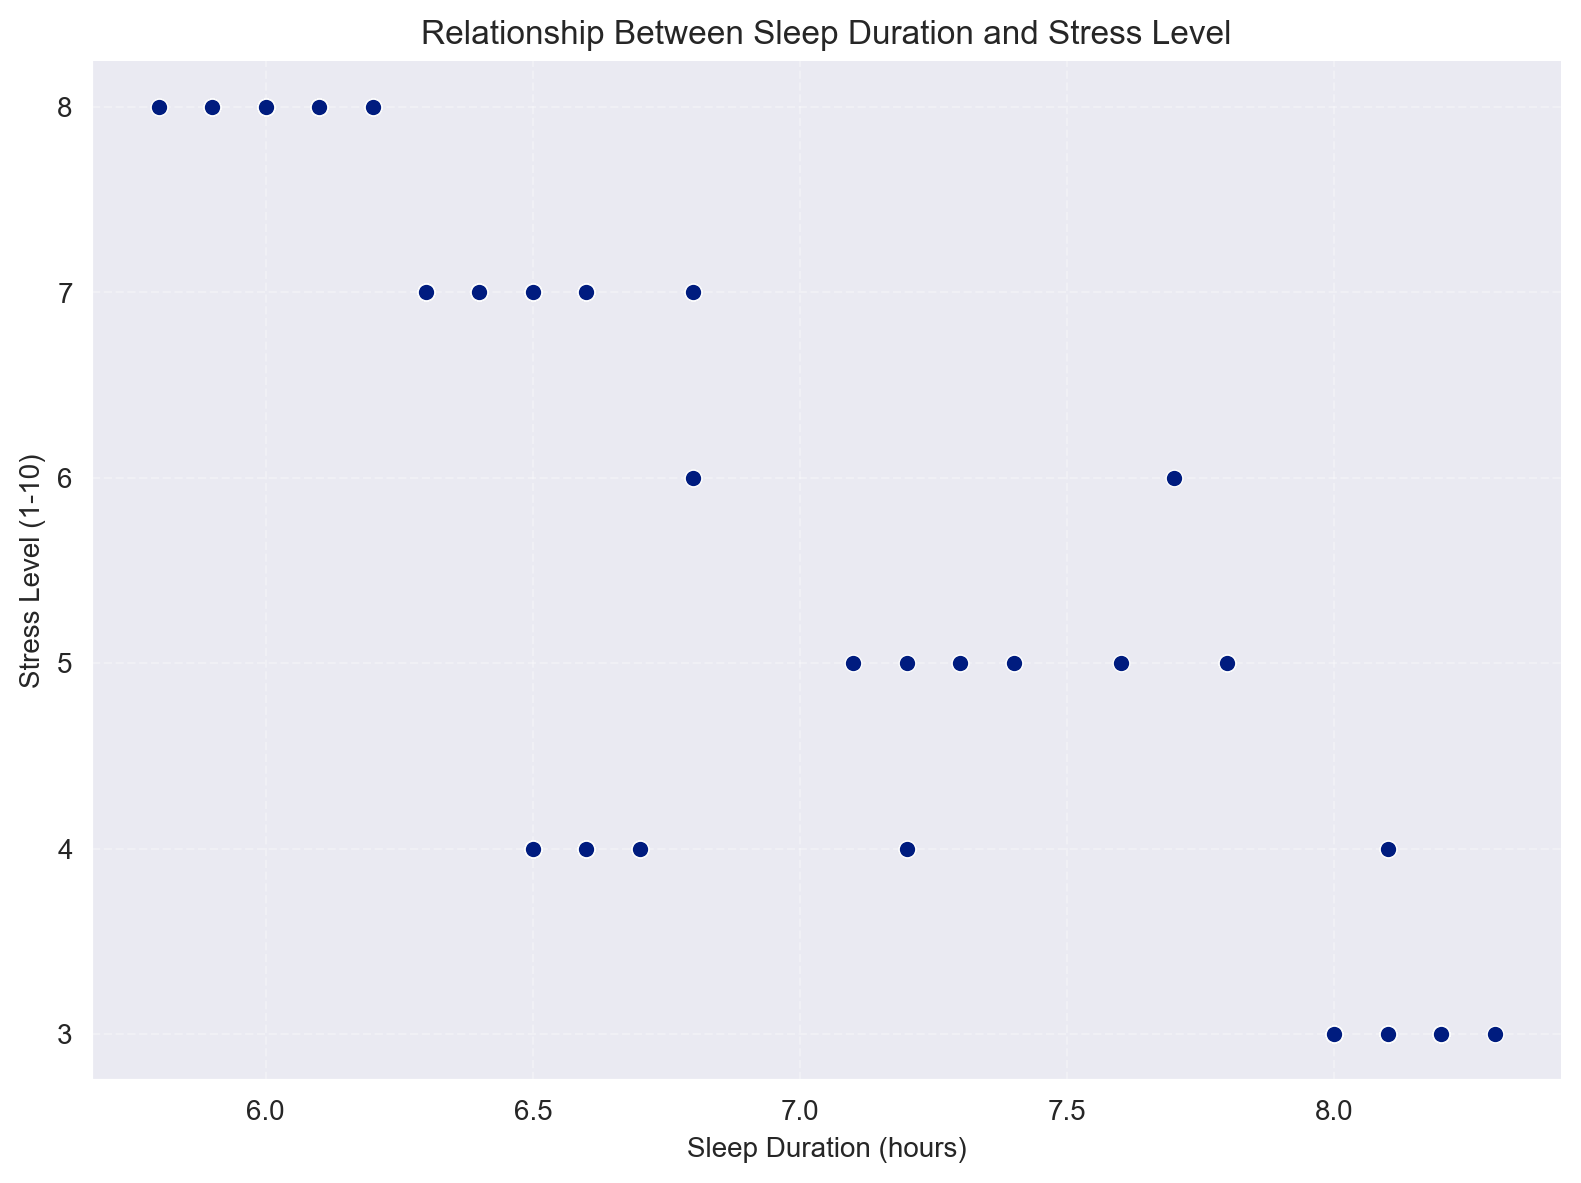

In [105]:
# create a scatterplot of `Sleep Duration` and `Stress Level`
# add a title "Relationship Between Sleep Duration and Stress Level"
# add a horizontal grid to the plot
# add horizontal axes label "Sleep Duration (hours)"
# add the vertical label "Stress Level (1-10)"
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='Sleep Duration', y='Stress Level', data=df, ax=ax)
ax.set_title('Relationship Between Sleep Duration and Stress Level')
ax.set_xlabel('Sleep Duration (hours)')
ax.set_ylabel('Stress Level (1-10)')
sns.despine(ax=ax, right=True, top=True)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

The scatter plot shows a negative relationship between `Sleep Duration` and `Stress Level,` with longer sleep generally associated with lower stress.

In [106]:
# create a linear regression model with `age` add `stress level` as the independent variable and `sleep duration` as the dependent variable
# use the statsmodels package to fit an ordinary least squares (OLS) regression model to the data
X = df['Stress Level']
y = df['Sleep Duration']
X = sm.add_constant(X)  # add a constant term to the independent variable
model = sm.OLS(y, X).fit()  # fit the OLS regression model
print(model.summary())  # print the summary of the regression model

                            OLS Regression Results                            
Dep. Variable:         Sleep Duration   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     394.6
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           3.29e-44
Time:                        11:22:51   Log-Likelihood:                -80.815
No. Observations:                 155   AIC:                             165.6
Df Residuals:                     153   BIC:                             171.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            8.7577      0.103     84.753   

F-statistic: 
R-squared: the model explains $72\%$ of the model variance.
p-value: the p-value is less thna 0.05, so Stress Level is statistically significant.

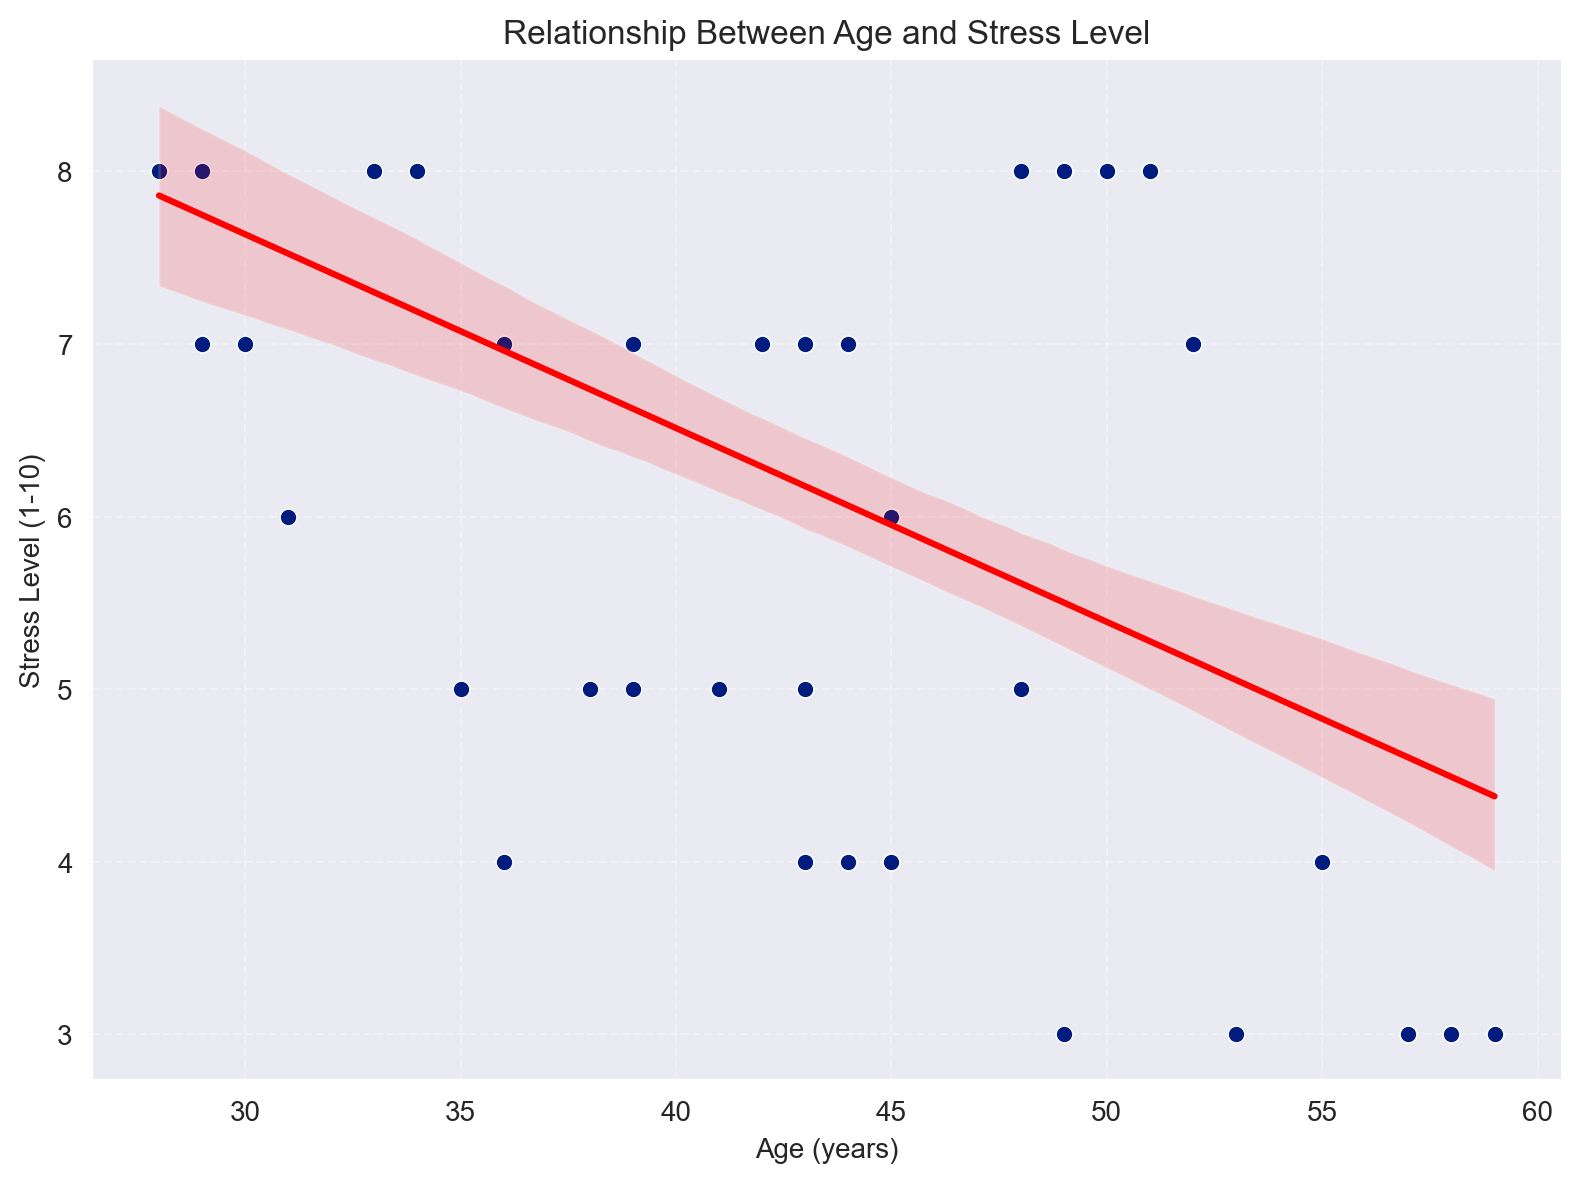

In [107]:
# recreate the scatterplot of `Age` and `Stress Level` but add a regression line to visualize the relationship between age and stress level for patients in the dataset
fig, ax = plt.subplots(figsize=(8, 6)) 
sns.scatterplot(x='Age', y='Stress Level', data=df, ax=ax)
sns.regplot(x='Age', y='Stress Level', data=df, scatter=False, ax=ax, color='red')
ax.set_title('Relationship Between Age and Stress Level')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Stress Level (1-10)')   
sns.despine(ax=ax, right=True, top=True)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

The plot shows a clear negative relationship between `Age` and `Stress Level,` with stress generally decreasing as age increases.

## Discussion

The results of this analysis highlight several important relationships between sleep disorders and health-related factors such as age and BMI. The dataset shows a nearly even distribution between individuals diagnosed with insomnia ($49.7\%$) and sleep apnea ($50.3\%$), allowing for a balanced comparison between the two conditions.

One of the most notable findings is the difference in age distribution between the two groups. Individuals with sleep apnea tend to be older, with a higher mean age (approximately 49.7 years) compared to those with insomnia (approximately 43.5 years). This aligns with existing research suggesting that sleep apnea is more prevalent in middle-aged and older adults, potentially due to physiological changes such as airway obstruction and increased body mass. In contrast, insomnia appears more evenly distributed across slightly younger age ranges, indicating that it may be influenced more by behavioral or psychological factors rather than purely physiological ones.

BMI also appears to play a significant role in sleep health outcomes. The majority of participants fall into the “Overweight” category, with relatively few individuals classified as normal weight or obese. Given that sleep apnea is strongly associated with excess body weight, this distribution may help explain the relatively high prevalence of sleep apnea observed in the dataset. Increased body mass can contribute to airway obstruction during sleep, which is a key mechanism underlying sleep apnea. While the dataset does not explicitly quantify BMI differences between disorder groups in detail, the overall trend supports well-established links between weight and sleep-related breathing disorders.

Additionally, the analysis reinforces the idea that sleep disorders are multifactorial. While age and BMI show clear associations, they do not fully explain the presence of insomnia or sleep apnea. Other factors, such as stress levels, lifestyle habits, physical activity, and underlying health conditions, likely contribute to the development and severity of these disorders. This reflects the broader scientific understanding that sleep health is influenced by both biological and behavioral components.

There are also some limitations to consider. The sample size is relatively small (155 participants after filtering), which may limit the generalizability of the findings. The dataset also appears to simplify sleep disorders into only two categories, excluding individuals without a diagnosed disorder or with other conditions. Furthermore, the analysis is primarily descriptive, meaning causal relationships cannot be established. Future work could incorporate more advanced statistical modeling or machine learning techniques to better understand predictive relationships and interactions between variables.

## Conclusion

In conclusion, this project demonstrates a clear relationship between sleep disorders and key health indicators such as age and BMI. Sleep apnea is more commonly observed in older individuals and is likely associated with higher body weight, while insomnia appears more evenly distributed across a slightly younger population. These findings are consistent with existing research and reinforce the importance of considering both physiological and lifestyle factors when examining sleep health.

Overall, the analysis highlights the value of data-driven approaches in understanding health outcomes. By identifying patterns and associations in sleep-related data, this project contributes to a better understanding of how sleep disorders are linked to broader health risks. Improving sleep health, through interventions targeting weight management, stress reduction, and healthy sleep habits, may play a critical role in enhancing overall well-being.

Future research could expand on this work by including larger and more diverse datasets, additional variables such as stress or activity levels, and predictive modeling techniques to better assess risk factors. Such efforts would provide deeper insights into the complex relationship between sleep and health, ultimately supporting more effective prevention and treatment strategies.